In [1]:
# Библиотеки
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from itertools import combinations
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Загрузка датасета
from google.colab import drive
drive.mount('/content/drive')

baskets = '/content/drive/MyDrive/baskets.csv'

df = pd.read_csv(baskets, sep=',', header=None, encoding='cp1251')
df.head()

Mounted at /content/drive


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,креветки,миндаль,авокадо,овощная смесь,зеленый виноград,цельнозерновая мука,батат,творог,энергетический напиток,томатный сок,низкокалорийный йогурт,зеленый чай,мед,салат,минеральная вода,лосось,ягодный сок,замороженный смузи,шпинат,оливковое масло
1,гамбургер,фрикадельки,яйца,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,чатни,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,индейка,авокадо,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,минеральная вода,молоко,энергетический батончик,рис,зеленый чай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# one-hot преобразование транзакций
transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_onehot = pd.DataFrame(te_array, columns=te.columns_)
# df_onehot = df_onehot.fillna(0)
df_onehot.head()

,авокадо,аксессуары,баклажаны,батат,батончик без глютена,бекон,белое вино,белый сыр,блинчики,ветчина,...,чили,шампанское,шампунь,шоколад,шпинат,энергетический батончик,энергетический напиток,эскалоп,ягодный сок,яйца
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [4]:
min_support = 0.01                                            # Фиксируем минимальную поддержку на 10%
confidence_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.6, 0.7]       # Варьируем значение пороговой поддержки

summary_rules = []                                            # Результаты
rules_by_confidence = {}                                      # Список правил

frequent_itemsets = apriori(df_onehot,
                            min_support=min_support,
                            use_colnames=True)

for conf in confidence_values:

    print(f"Поддержка: {conf}")
    start_time = time.perf_counter()

    rules = association_rules(frequent_itemsets,
                              metric="confidence",
                              min_threshold=conf)

    end_time = time.perf_counter()
    execution_time = end_time - start_time

    if len(rules) > 0:
        rules["rule_length"] = (
            rules["antecedents"].apply(len) +
            rules["consequents"].apply(len)
        )
        max_length = rules["rule_length"].max()
    else:
        rules["rule_length"] = []
        max_length = 0

    print("┌--------------------------------------------------------┐")
    print(f"| Время: {execution_time:.4f} сек, правил: {len(rules)}, максимальная длина: {max_length}  |")
    print("└--------------------------------------------------------┘\n")

    summary_rules.append({
        "confidence": conf,
        "time_sec": execution_time,
        "total_rules": len(rules),
        "max_rule_length": max_length,
    })

    rules_by_confidence[conf] = rules


Поддержка: 0.1
┌--------------------------------------------------------┐
| Время: 0.0054 сек, правил: 333, максимальная длина: 3  |
└--------------------------------------------------------┘

Поддержка: 0.15
┌--------------------------------------------------------┐
| Время: 0.0045 сек, правил: 231, максимальная длина: 3  |
└--------------------------------------------------------┘

Поддержка: 0.2
┌--------------------------------------------------------┐
| Время: 0.0046 сек, правил: 163, максимальная длина: 3  |
└--------------------------------------------------------┘

Поддержка: 0.25
┌--------------------------------------------------------┐
| Время: 0.0040 сек, правил: 99, максимальная длина: 3  |
└--------------------------------------------------------┘

Поддержка: 0.3
┌--------------------------------------------------------┐
| Время: 0.0079 сек, правил: 65, максимальная длина: 3  |
└--------------------------------------------------------┘

Поддержка: 0.35
┌------------------

In [5]:
conf_example = 0.2
rules_to_show = rules_by_confidence[conf_example]

print(f"\nПравила при confidence = {conf_example}\n")

for _, row in rules_to_show.iterrows():
    antecedent = ", ".join(list(row["antecedents"]))
    consequent = ", ".join(list(row["consequents"]))
    print(f"{antecedent} ==> {consequent}")



Правила при confidence = 0.2

авокадо ==> минеральная вода
блинчики ==> картофель-фри
блинчики ==> макароны
блинчики ==> минеральная вода
блинчики ==> шоколад
блинчики ==> яйца
гамбургер ==> зеленый чай
гамбургер ==> картофель-фри
гамбургер ==> макароны
гамбургер ==> минеральная вода
гамбургер ==> молоко
гамбургер ==> яйца
говяжий фарш ==> макароны
макароны ==> говяжий фарш
говяжий фарш ==> минеральная вода
говяжий фарш ==> молоко
оливковое масло ==> говяжий фарш
тертый сыр ==> говяжий фарш
травы и перец ==> говяжий фарш
говяжий фарш ==> шоколад
говяжий фарш ==> яйца
креветки ==> замороженные овощи
замороженные овощи ==> макароны
замороженные овощи ==> минеральная вода
замороженные овощи ==> молоко
помидоры ==> замороженные овощи
замороженные овощи ==> шоколад
замороженные овощи ==> яйца
замороженный смузи ==> картофель-фри
замороженный смузи ==> макароны
замороженный смузи ==> минеральная вода
замороженный смузи ==> молоко
замороженный смузи ==> шоколад
зеленый чай ==> картофель-фри


In [6]:
results_df = pd.DataFrame(summary_rules)
results_df

,confidence,time_sec,total_rules,max_rule_length
0,0.10,0.005411,333,3
1,0.15,0.004518,231,3
2,0.20,0.004562,163,3
3,0.25,0.004030,99,3
4,0.30,0.007878,65,3
5,0.35,0.003626,34,3
6,0.40,0.005250,19,3
7,0.45,0.004710,6,3
8,0.50,0.003510,2,3
9,0.55,0.001827,0,0


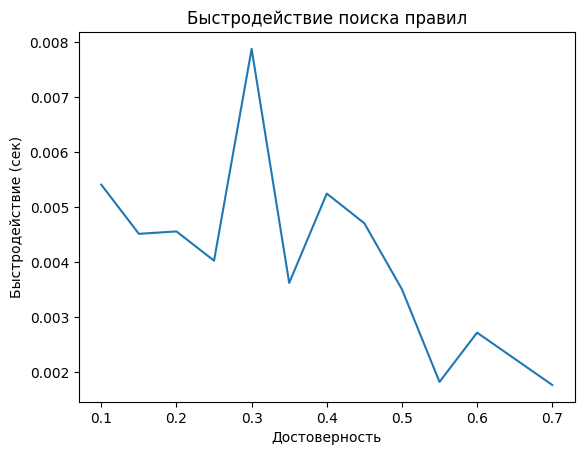

In [7]:
plt.figure()
plt.plot(results_df["confidence"], results_df["time_sec"])
plt.xlabel("Достоверность")
plt.ylabel("Быстродействие (сек)")
plt.title("Быстродействие поиска правил")
plt.show()

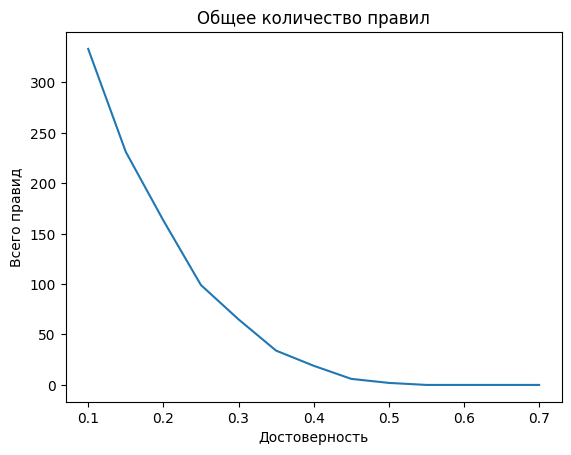

In [8]:
plt.figure()
plt.plot(results_df["confidence"], results_df["total_rules"])
plt.xlabel("Достоверность")
plt.ylabel("Всего правид")
plt.title("Общее количество правил")
plt.show()

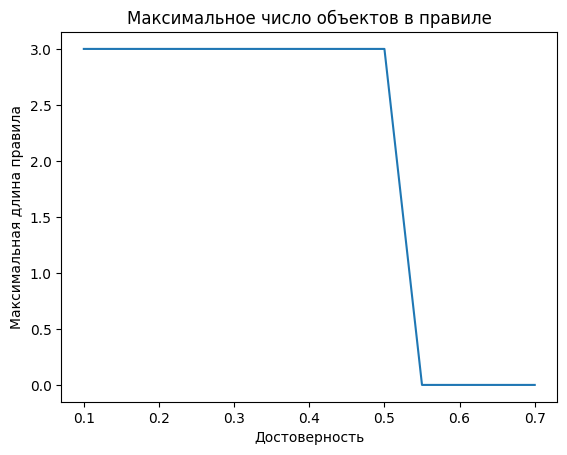

In [9]:
plt.figure()
plt.plot(results_df["confidence"], results_df["max_rule_length"])
plt.xlabel("Достоверность")
plt.ylabel("Максимальная длина правила")
plt.title("Максимальное число объектов в правиле")
plt.show()

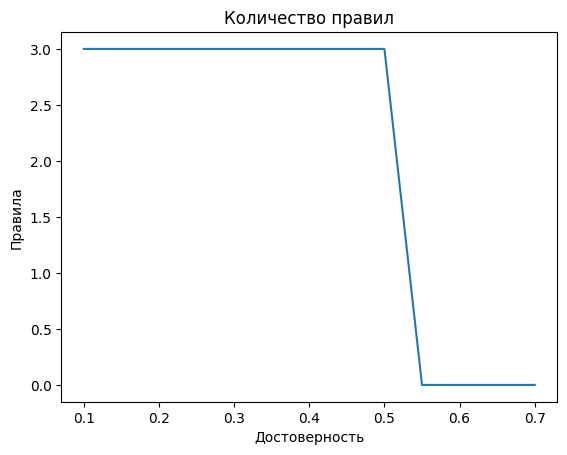

In [10]:
plt.figure()
plt.plot(results_df["confidence"], results_df["max_rule_length"])
plt.xlabel("Достоверность")
plt.ylabel("Правила")
plt.title("Количество правил")
plt.show()